# mask-to-mri — Synthetic MRI Generation with pix2pix

This notebook runs the full pipeline: data exploration → model training → evaluation.

**Experiment A:** Train pix2pix to generate realistic MRI from masks.  
**Experiment B:** Measure segmentation improvement with synthetic data.

## 0 — Colab Setup

In [1]:
import os, shutil, glob

# --- 1. Clone / update repo ---
os.chdir('/content')
if not os.path.exists('Mask-to-MRI'):
    !git clone https://github.com/AmineAitLaamim/Mask-to-MRI
os.chdir('Mask-to-MRI')
!git pull origin main 2>/dev/null || true

# --- 2. Install dependencies ---
!pip install -q uv
!pip install -q torch torchvision albumentations opencv-python tifffile scikit-image pytorch-fid segmentation-models-pytorch pyyaml matplotlib numpy Pillow tqdm

# --- 3. Mount Drive (read-only for dataset zip) ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# --- 4. Optimized Dataset Setup: copy zip locally, unzip, symlink ---
os.makedirs('data/raw', exist_ok=True)

local_folder = '/content/lgg-mri-segmentation'
link_path = 'data/raw/lgg-mri-segmentation'
zip_local = '/content/lgg-mri-segmentation.zip'

# Clean up old link
if os.path.islink(link_path):
    os.remove(link_path)
elif os.path.isdir(link_path):
    shutil.rmtree(link_path)
elif os.path.exists(link_path):
    os.remove(link_path)

# Extract only if local folder doesn't exist yet
if not os.path.exists(local_folder):
    # Find zip in Drive (handle 'MyDrive' vs 'My Drive')
    zip_drive = None
    for candidate in [
        '/content/drive/MyDrive/mask-to-mri/dataset/lgg-mri-segmentation.zip',
        '/content/drive/My Drive/mask-to-mri/dataset/lgg-mri-segmentation.zip',
    ]:
        if os.path.exists(candidate):
            zip_drive = candidate
            break

    if zip_drive:
        print(f"Found zip: {zip_drive}")
        # Single-file copy to local disk (much faster than unzipping from Drive)
        if not os.path.exists(zip_local):
            print("Copying zip to local disk...")
            shutil.copy2(zip_drive, zip_local)
            print("Copy complete.")
        # Unzip locally (fast local disk I/O)
        print("Unzipping to local disk...")
        !unzip -q -o "$zip_local" -d /content/
        print("Unzip complete.")
    else:
        print("ERROR: Zip not found in Drive at mask-to-mri/dataset/")
        print("Upload 'lgg-mri-segmentation.zip' to MyDrive/mask-to-mri/dataset/")

# Create symlink from repo → local folder
if os.path.exists(local_folder) and not os.path.exists(link_path):
    os.symlink(local_folder, link_path)
    print("Dataset linked successfully.")
elif os.path.exists(link_path):
    print("Dataset already linked.")

# --- 5. Symlink outputs TO Drive (persists across disconnects) ---
drive_outputs = '/content/drive/MyDrive/mask-to-mri/outputs'
os.makedirs(drive_outputs, exist_ok=True)
# CRITICAL FIX: Create local outputs folder first!
os.makedirs('outputs', exist_ok=True)
for d in ['checkpoints', 'samples', 'metrics']:
    local_dir = f'outputs/{d}'
    remote_dir = f'{drive_outputs}/{d}'
    os.makedirs(remote_dir, exist_ok=True)
    if os.path.islink(local_dir):
        os.remove(local_dir)
    elif os.path.exists(local_dir):
        shutil.rmtree(local_dir)
    os.symlink(remote_dir, local_dir)

print(f"Working dir: {os.getcwd()}")
print("Files:", os.listdir('.'))

Cloning into 'Mask-to-MRI'...
remote: Enumerating objects: 205, done.
remote: Counting objects: 100% (205/205), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 205 (delta 131), reused 205 (delta 131), pack-reused 0 (from 0)
Receiving objects: 100% (205/205), 1.31 MiB | 16.21 MiB/s, done.
Resolving deltas: 100% (131/131), done.
Already up to date.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00
Mounted at /content/drive
Found zip: /content/drive/MyDrive/mask-to-mri/dataset/lgg-mri-segmentation.zip
Copying zip to local disk...
Copy complete.
Unzipping to local disk...
Unzip complete.
Dataset linked successfully.
Working dir: /content/Mask-to-MRI
Files: ['data', 'src', 'mask_to_mri.ipynb', 'pyproject.toml', '.git', 'README.md', '.python-version', 'uv.lock', 'requirements.txt', 'notebooks', 'outputs', '.gitignore', 'prepare_splits.py', 'mask_to_mri_cpu.ipynb',

## 1 — Config & Imports

In [2]:
import sys
sys.path.insert(0, '.')

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt

with open('config.yaml') as f:
    config = yaml.safe_load(f)

print("Configuration:")
print(yaml.dump(config, default_flow_style=False))

from src.utils import fix_seed
fix_seed(config['data']['seed'], benchmark=True)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Device: {device}")

Configuration:
data:
  balanced: true
  image_size: 256
  processed_dir: data/processed
  raw_dir: data/raw/lgg-mri-segmentation
  seed: 42
  synthetic_dir: data/synthetic
  tumor_ratio: 0.8
model:
  input_channels: 1
  norm: instance
  num_filters: 64
  output_channels: 3
paths:
  checkpoints: outputs/checkpoints
  metrics: outputs/metrics
  samples: outputs/samples
training:
  batch_size: 1
  beta1: 0.5
  beta2: 0.999
  epochs: 200
  lambda_l1: 20
  lambda_perceptual: 3
  lr: 0.0002
  save_every: 5

  → Random seed fixed: 42 (cudnn.benchmark=True)
Device: cuda


## 2 — Data Exploration

In [3]:
from src.dataset import get_patient_file_list
import tifffile
import os

raw_dir = config['data']['raw_dir']
patient_data = get_patient_file_list(raw_dir)

print(f"Total patients: {len(patient_data)}")
print(f"Sample patients: {list(patient_data.keys())[:5]}")

total_slices = sum(len(v) for v in patient_data.values())
slices_per_patient = [len(v) for v in patient_data.values()]
print(f"Total slices: {total_slices}")
print(f"Per patient: min={min(slices_per_patient)}, max={max(slices_per_patient)}, avg={np.mean(slices_per_patient):.1f}")

Total patients: 110
Sample patients: ['TCGA_CS_4941_19960909', 'TCGA_CS_4942_19970222', 'TCGA_CS_4943_20000902', 'TCGA_CS_4944_20010208', 'TCGA_CS_5393_19990606']
Total slices: 3929
Per patient: min=20, max=88, avg=35.7


Patient: TCGA_CS_4941_19960909 | Tumor slice: 1
Image: (256, 256, 3) uint8
  R/T1: min=0, max=207, mean=42.2
  G/FLAIR: min=0, max=222, mean=42.3
  B/T2: min=0, max=248, mean=42.5
Mask values: [  0 255]


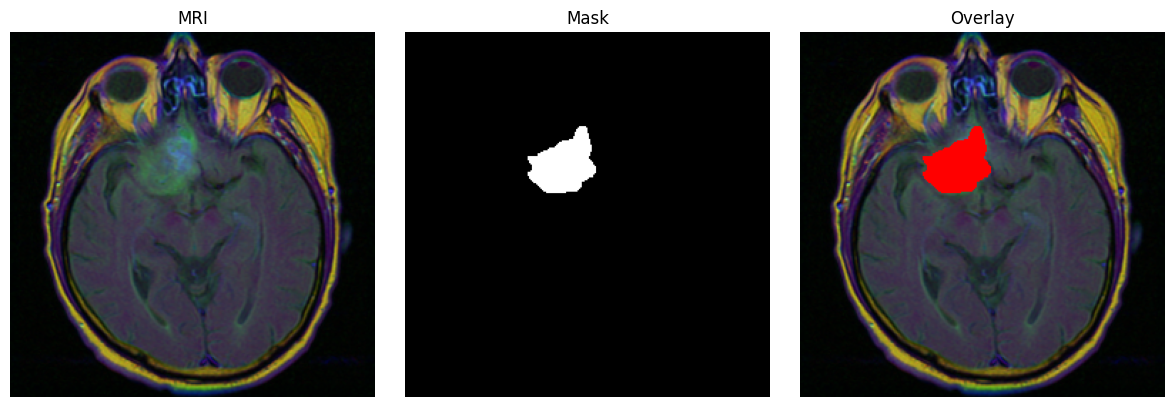

In [4]:
# Find a slice with tumor pixels
first_patient = list(patient_data.keys())[0]
p_dir = os.path.join(raw_dir, first_patient)
mask_files = sorted([f for f in os.listdir(p_dir) if f.endswith('_mask.tif')])

tumor_idx = None
for i, mf in enumerate(mask_files):
    m = tifffile.imread(os.path.join(p_dir, mf))
    if m.max() > 0:
        tumor_idx = i
        mask_path = os.path.join(p_dir, mf)
        img_path = os.path.join(p_dir, mf.replace('_mask.tif', '.tif'))
        break

if tumor_idx is not None:
    image = tifffile.imread(img_path)
    mask = tifffile.imread(mask_path)

    print(f"Patient: {first_patient} | Tumor slice: {tumor_idx}")
    print(f"Image: {image.shape} {image.dtype}")
    for i, ch in enumerate(['R/T1', 'G/FLAIR', 'B/T2']):
        print(f"  {ch}: min={image[:,:,i].min()}, max={image[:,:,i].max()}, mean={image[:,:,i].mean():.1f}")
    print(f"Mask values: {np.unique(mask)}")

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image); axes[0].set_title('MRI'); axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Mask'); axes[1].axis('off')
    overlay = image.copy()
    overlay[mask > 0] = [255, 0, 0]
    axes[2].imshow(overlay); axes[2].set_title('Overlay'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No tumor found in first patient.")

## 3 — DataLoaders (includes background slices)

In [5]:
import json
import os, shutil
from pathlib import Path
from src.dataset import LGGDataset, BalancedLGGDataset

raw_dir = config['data']['raw_dir']
dataset_root = raw_dir  # raw_dir is already 'data/raw/lgg-mri-segmentation'
balanced = config['data']['balanced']
tumor_ratio = config['data']['tumor_ratio']
image_size = config['data']['image_size']
seed = config['data']['seed']

# --- Locate splits: prefer Drive, fall back to generating locally ---
splits_candidates = [
    '/content/drive/MyDrive/mask-to-mri/dataset/splits',
    '/content/drive/My Drive/mask-to-mri/dataset/splits',
    'data/splits',
]
splits_path = None
for candidate in splits_candidates:
    if all(os.path.exists(f'{candidate}/{s}_split.json') for s in ['train', 'val', 'test']):
        splits_path = candidate
        break

if splits_path is None:
    print("Splits not found. Generating locally with prepare_splits.py...")
    !uv run python prepare_splits.py
    splits_path = 'data/splits'
    # Copy to Drive for future runs
    drive_splits = '/content/drive/MyDrive/mask-to-mri/dataset/splits'
    os.makedirs(drive_splits, exist_ok=True)
    for name in ['train_split.json', 'val_split.json', 'test_split.json',
                 'train_tumor.json', 'train_background.json']:
        local = f'data/splits/{name}'
        if os.path.exists(local):
            shutil.copy(local, f'{drive_splits}/{name}')
    print(f"Splits copied to Drive at {drive_splits}.")

print(f"Using splits from: {splits_path}")

# --- Load split helper ---
def load_split(name):
    with open(f'{splits_path}/{name}_split.json') as f:
        pairs = json.load(f)
    return [(f"{dataset_root}/{p[0]}", f"{dataset_root}/{p[1]}") for p in pairs]

val_pairs = load_split('val')
test_pairs = load_split('test')

print(f"Balanced training: {balanced}, Tumor ratio: {tumor_ratio}, Image size: {image_size}")

# --- Build training dataset ---
tumor_path = f'{splits_path}/train_tumor.json'
bg_path = f'{splits_path}/train_background.json'

if balanced and os.path.exists(tumor_path) and os.path.exists(bg_path):
    print("Loading separated lists (Fast Mode)...")
    with open(tumor_path) as f:
        train_tumor = [(f"{dataset_root}/{p[0]}", f"{dataset_root}/{p[1]}") for p in json.load(f)]
    with open(bg_path) as f:
        train_bg = [(f"{dataset_root}/{p[0]}", f"{dataset_root}/{p[1]}") for p in json.load(f)]
    train_ds = BalancedLGGDataset(
        tumor_pairs=train_tumor, background_pairs=train_bg,
        image_size=image_size, augment=True, tumor_ratio=tumor_ratio, cache=True, seed=seed
    )
else:
    print("Separated lists not found. Building from mixed train split (scans masks)...")
    train_pairs = load_split('train')
    train_ds = BalancedLGGDataset(
        pairs=train_pairs, image_size=image_size, augment=True,
        tumor_ratio=tumor_ratio, cache=True, seed=seed
    )

# Pre-build epoch indices for the initial epoch
train_ds.set_epoch(seed=seed)
print(f"Train dataset size: {len(train_ds)} slices")

# --- Worker init for reproducibility ---
def worker_init_fn(worker_id):
    import random as _random
    import numpy as _np
    worker_seed = torch.initial_seed() % 2**32
    _random.seed(worker_seed)
    _np.random.seed(worker_seed)

# --- Build DataLoaders ---
# BalancedLGGDataset uses set_epoch() for sampling; DataLoader uses no shuffle.
loaders = {
    'train': torch.utils.data.DataLoader(
        train_ds, batch_size=config['training']['batch_size'],
        shuffle=False,  # BalancedLGGDataset handles sampling via set_epoch()
        num_workers=2, pin_memory=torch.cuda.is_available(),
        worker_init_fn=worker_init_fn,
    ),
    'val': torch.utils.data.DataLoader(
        LGGDataset(val_pairs, image_size=image_size, augment=False, seed=seed,
                   filter_empty_masks=False, cache=True),
        batch_size=config['training']['batch_size'], shuffle=False, num_workers=0
    ),
    'test': torch.utils.data.DataLoader(
        LGGDataset(test_pairs, image_size=image_size, augment=False, seed=seed,
                   filter_empty_masks=False, cache=True),
        batch_size=config['training']['batch_size'], shuffle=False, num_workers=0
    ),
}
print(f"DataLoaders ready — Train: {len(loaders['train'])}, Val: {len(loaders['val'])}, Test: {len(loaders['test'])}")

Using splits from: /content/drive/MyDrive/mask-to-mri/dataset/splits
Balanced training: True, Tumor ratio: 0.8, Image size: 256
Loading separated lists (Fast Mode)...


/content/Mask-to-MRI/src/dataset.py:132: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),


    Tumor slices:      1065
    Background slices: 2068
    Tumor ratio:       0.8
    Caching raw images in RAM (Parallel Mode)...
    Cached 1065 tumor + 2068 bg pairs.
Train dataset size: 1331 slices
    Caching raw images in RAM (Parallel Mode)...
    Cached 151 pairs.
    Caching raw images in RAM (Parallel Mode)...
    Cached 157 pairs.
DataLoaders ready — Train: 1331, Val: 151, Test: 157


Mask: (1, 1, 256, 256)  Image: (1, 3, 256, 256)
Mask range: [-1.00, 1.00]
Image range: [-1.00, 1.00]


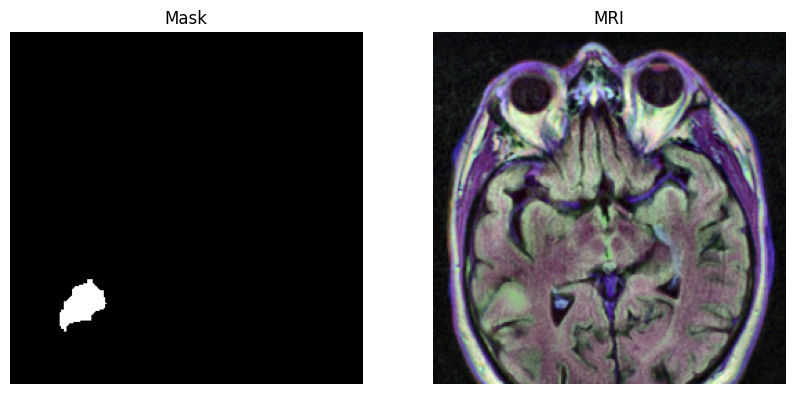

In [6]:
mask, img = next(iter(loaders['train']))
print(f"Mask: {tuple(mask.shape)}  Image: {tuple(img.shape)}")
print(f"Mask range: [{mask.min():.2f}, {mask.max():.2f}]")
print(f"Image range: [{img.min():.2f}, {img.max():.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
mask_vis = ((mask[0, 0].numpy() + 1.0) * 127.5).astype(np.uint8)
img_vis = ((img[0].numpy().transpose(1, 2, 0) + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
axes[0].imshow(mask_vis, cmap='gray'); axes[0].set_title('Mask'); axes[0].axis('off')
axes[1].imshow(img_vis); axes[1].set_title('MRI'); axes[1].axis('off')
plt.show()

## 4 — Models

In [7]:
import torch
from src.generator import create_generator
from src.discriminator import create_discriminator
from src.utils import print_model_summary

if torch.cuda.is_available():
    torch.cuda.empty_cache()

m = config['model']
G = create_generator(
    in_channels=m['input_channels'],
    out_channels=m['output_channels'],
    num_filters=m['num_filters'],
    norm=m['norm'],
).to(device)

D = create_discriminator(
    in_channels=m['input_channels'] + m['output_channels'],
    num_filters=m['num_filters'],
).to(device)

if torch.cuda.is_available():
    assert next(G.parameters()).device.type == device.type, "G not on GPU!"
    assert next(D.parameters()).device.type == device.type, "D not on GPU!"

print_model_summary('Generator (U-Net)', G)
print_model_summary('Discriminator (PatchGAN)', D)

  Generator (U-Net): 10,750,659 parameters (10.75M)
  Discriminator (PatchGAN): 2,765,761 parameters (2.77M)


In [8]:
with torch.no_grad():
    fake = G(mask.to(device))
    d_real = D(mask.to(device), img.to(device))
    d_fake = D(mask.to(device), fake)

assert fake.shape == img.shape, f"Shape mismatch: {fake.shape} != {img.shape}"
assert fake.min() >= -1.01 and fake.max() <= 1.01, f"fake range: [{fake.min():.3f}, {fake.max():.3f}]"

print(f"✓ G output: {tuple(fake.shape)}  range: [{fake.min():.3f}, {fake.max():.3f}]")
print(f"✓ D real: {tuple(d_real.shape)}")
print(f"✓ D fake: {tuple(d_fake.shape)}")
print("✓ All checks passed — ready to train")

✓ G output: (1, 3, 256, 256)  range: [-1.000, 1.000]
✓ D real: (1, 1, 30, 30)
✓ D fake: (1, 1, 30, 30)
✓ All checks passed — ready to train


## 5 — Training

In [9]:
import time, glob, os
from src.train import train, find_latest_checkpoint

print(f"lambda_l1 from config: {config['training']['lambda_l1']}")

if torch.cuda.is_available():
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {torch.cuda.get_device_name(0)} ({gpu_mem:.1f} GB total)")
    print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB\n")
else:
    print(f"Device: {device}\n")

ckpt = find_latest_checkpoint(config['paths']['checkpoints'])
if ckpt:
    print(f"Found checkpoint: {ckpt}")
    print("   Training will auto-resume from that epoch\n")
else:
    print("No checkpoint found — starting from epoch 1\n")

start = time.time()
try:
    history = train(
        train_loader=loaders['train'],
        val_loader=loaders['val'],
        generator=G,
        discriminator=D,
        config=config,
        device=device,
        checkpoint_dir=config['paths']['checkpoints'],
        samples_dir=config['paths']['samples'],
        metrics_dir=config['paths']['metrics'],
        resume_from="outputs/checkpoints/checkpoint_epoch_55.pt",
    )
    print(f"\nTraining complete in {time.time()-start:.0f}s")
except KeyboardInterrupt:
    elapsed = time.time() - start
    print(f"\nTraining interrupted after {elapsed:.0f}s")
    print("Checkpoint already saved — resume by re-running this cell")

lambda_l1 from config: 20
GPU: Tesla T4 (15.6 GB total)
Allocated: 0.08 GB

Found checkpoint: outputs/checkpoints/checkpoint_epoch_55.pt
   Training will auto-resume from that epoch

  → Mixed Precision (AMP) enabled for ~2x speedup
  → Resuming from checkpoint: outputs/checkpoints/checkpoint_epoch_55.pt (epoch 55)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 71.1MB/s]



Training pix2pix: epoch 56–200 of 200
  LR=0.0002, beta1=0.5, lambda_L1=20, lambda_perceptual=3
  Schedule: 100 epochs constant + 100 epochs linear decay
  Checkpoint every 5 epochs
  Metrics dir: outputs/metrics



Epoch 56/200 | D: 0.0757 | G: 8.1363 | G_adv: 0.7190 | G_L1: 0.2136 | G_perc: 1.0482 | LR: 0.000200


Epoch 57/200 | D: 0.0752 | G: 8.0452 | G_adv: 0.7231 | G_L1: 0.2116 | G_perc: 1.0301 | LR: 0.000200


...

Epoch 196/200 | D: 0.0537 | G: 8.0421 | G_adv: 0.7773 | G_L1: 0.2087 | G_perc: 1.0305 | LR: 0.000008


Epoch 197/200 | D: 0.0514 | G: 7.9593 | G_adv: 0.7887 | G_L1: 0.2034 | G_perc: 1.0340 | LR: 0.000006


Epoch 198/200 | D: 0.0515 | G: 7.9869 | G_adv: 0.7878 | G_L1: 0.2034 | G_perc: 1.0438 | LR: 0.000004


Epoch 199/200 | D: 0.0488 | G: 8.0244 | G_adv: 0.7945 | G_L1: 0.2050 | G_perc: 1.0435 | LR: 0.000002


Epoch 200/200 | D: 0.0509 | G: 8.0082 | G_adv: 0.7934 | G_L1: 0.2033 | G_perc: 1.0497 | LR: 0.000000
  → Saved checkpoint: outputs/checkpoints/checkpoint_epoch_200.pt
  → Saved sample grid: outputs/samples/samples_epoch_200.png

Training complete.

Training complete in 7642s


### Live Loss Plot (run this cell during or after training)

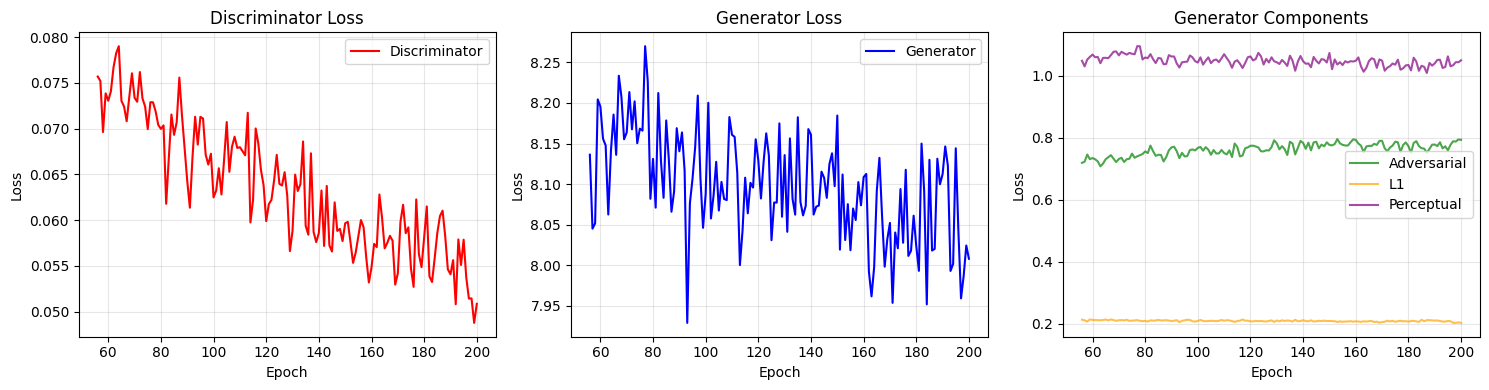

Loss plot updated. Run this cell again to refresh.


In [10]:
from IPython.display import Image, display, clear_output
import os

plot_path = 'outputs/samples/loss_curves.png'
if os.path.exists(plot_path):
    clear_output(wait=True)
    display(Image(filename=plot_path))
    print("Loss plot updated. Run this cell again to refresh.")
else:
    print("Plot not ready yet — training must complete at least 1 checkpoint (every 5 epochs).")

### Reload Metrics (after crash or restart)

In [11]:
import os
from src.train import load_metrics
from src.utils import plot_loss_curves

metrics_path = 'outputs/metrics/training_history.json'
if os.path.exists(metrics_path):
    history = load_metrics(metrics_path)
    print(f"Loaded {len(history)} epochs of metrics")
    plot_loss_curves(history)
else:
    print("No metrics found yet — training must complete at least 1 checkpoint.")

Loaded 145 epochs of metrics


## 6 — Generate Synthetic MRI

In [12]:
import os, glob
import numpy as np
from PIL import Image
from src.train import load_checkpoint

ckpts = sorted(glob.glob('outputs/checkpoints/checkpoint_epoch_*.pt'))
if ckpts:
    epoch = load_checkpoint(ckpts[-1], G, D)
    print(f"Loaded epoch {epoch}")

G.eval()
syn_dir = config['data']['synthetic_dir']
os.makedirs(syn_dir, exist_ok=True)

count = 0
with torch.no_grad():
    for mask, real in loaders['test']:
        fake = G(mask.to(device))
        fake_np = ((fake[0].cpu().permute(1, 2, 0).numpy() + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
        real_np = ((real[0].cpu().permute(1, 2, 0).numpy() + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
        Image.fromarray(fake_np).save(os.path.join(syn_dir, f'fake_{count:04d}.png'))
        Image.fromarray(real_np).save(os.path.join(syn_dir, f'real_{count:04d}.png'))
        count += 1
print(f"Saved {count} pairs to {syn_dir}")

Loaded epoch 95
Saved 157 pairs to data/synthetic


## 7 — Evaluation (Exp A)

In [13]:
import numpy as np
from src.evaluate import compute_ssim_batch, compute_psnr_batch, save_eval_results

all_ssim, all_psnr = [], []
G.eval()
with torch.no_grad():
    for mask, real in loaders['test']:
        fake = G(mask.to(device))
        all_ssim.append(compute_ssim_batch(fake, real))
        all_psnr.append(compute_psnr_batch(fake, real))

mean_ssim = np.mean(all_ssim)
mean_psnr = np.mean(all_psnr)
print(f"SSIM: {mean_ssim:.4f}")
print(f"PSNR: {mean_psnr:.2f} dB")

SSIM: 0.5142
PSNR: 19.43 dB


In [14]:
metrics = {
    'ssim': round(float(mean_ssim), 4),
    'psnr': round(float(mean_psnr), 2),
}
save_eval_results(metrics, metrics_dir=config['paths']['metrics'], prefix='eval_exp_a')

  → Saved evaluation results: outputs/metrics/eval_exp_a_20260406_005517.json


'outputs/metrics/eval_exp_a_20260406_005517.json'

## 8 — Experiment B (Segmentation)

In [15]:
import numpy as np
import segmentation_models_pytorch as smp
from tqdm import tqdm
from src.losses import DiceBCELoss
from src.evaluate import compute_dice_score

def train_segmentation(train_loader, val_loader, epochs=50):
    torch.cuda.empty_cache()
    model = smp.Unet(
        encoder_name="resnet18",
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation="sigmoid",
    ).to(device)
    criterion = DiceBCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    for ep in range(1, epochs + 1):
        model.train()
        loss_sum = 0
        for img, mask in tqdm(train_loader, desc=f"Seg {ep}/{epochs}", leave=False):
            img, mask = img.to(device), mask.to(device)
            mask_bin = (mask + 1.0) / 2.0
            pred = model(img)
            loss = criterion(pred, mask_bin)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
        if ep % 10 == 0:
            print(f"  Ep {ep}: loss={loss_sum/len(train_loader):.4f}")

    model.eval()
    dices = []
    with torch.no_grad():
        for img, mask in val_loader:
            pred = model(img.to(device))
            pred_b = (pred.cpu().numpy() > 0.5).astype(np.float32)
            mask_b = ((mask + 1.0) / 2.0).numpy()
            dices.append(compute_dice_score(pred_b, mask_b))
    return np.mean(dices)

# dice_real = train_segmentation(loaders['train'], loaders['test'], epochs=50)
# print(f"Dice (real only): {dice_real:.4f}")

## 9 — Final Results

In [16]:
print("=" * 50)
print("mask-to-mri — Results")
print("=" * 50)
print(f"SSIM: {mean_ssim:.4f}")
print(f"PSNR: {mean_psnr:.2f} dB")
print(f"Synthetic samples: {count}")
print("=" * 50)

mask-to-mri — Results
SSIM: 0.5142
PSNR: 19.43 dB
Synthetic samples: 157
